{(100, 190, 10, 'baseline_heurs', 0): (np.float64(0.015699758789273176), np.float64(0.0015374928267191652)), (100, 190, 10, 'rl_heurs', 0): (np.float64(0.011274851618107113), np.float64(0.006007913624331676)), (100, 189, 10, 'baseline_heurs', 0): (np.float64(0.009518477043673012), np.float64(0.0)), (100, 189, 10, 'rl_heurs', 0): (np.float64(0.010918253079507279), np.float64(0.0)), (100, 194, 10, 'baseline_heurs', 0): (np.float64(0.009495973727911384), np.float64(0.009134607212056544)), (100, 194, 10, 'rl_heurs', 0): (np.float64(0.016600911867631272), np.float64(0.0061394435504591085)), (100, 137, 10, 'baseline_heurs', 0): (np.float64(0.011896755276563965), np.float64(0.007635857210356163)), (100, 137, 10, 'rl_heurs', 0): (np.float64(0.01424098659036354), np.float64(0.009357833468633508)), (100, 199, 10, 'baseline_heurs', 0): (np.float64(0.01366510139712474), np.float64(0.01172146680042892)), (100, 199, 10, 'rl_heurs', 0): (np.float64(0.01652220238814812), np.float64(0.00032524741568294

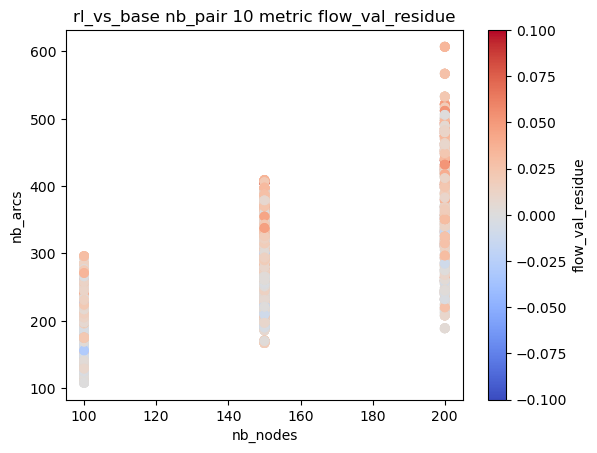

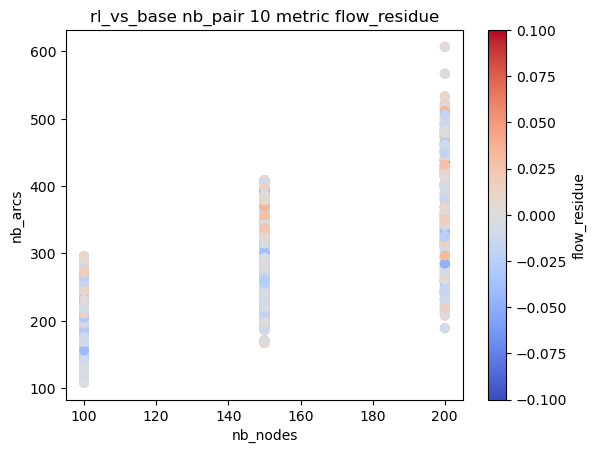

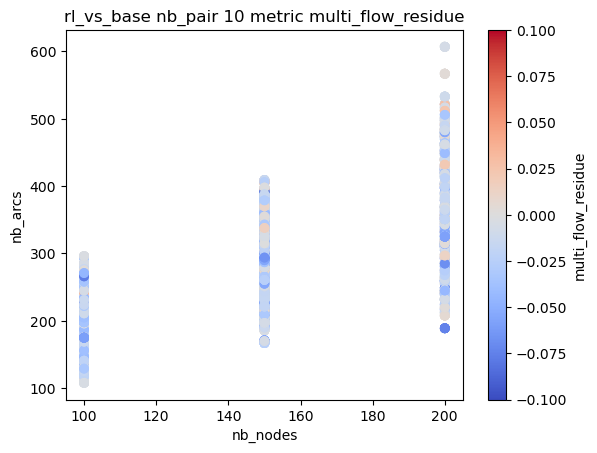

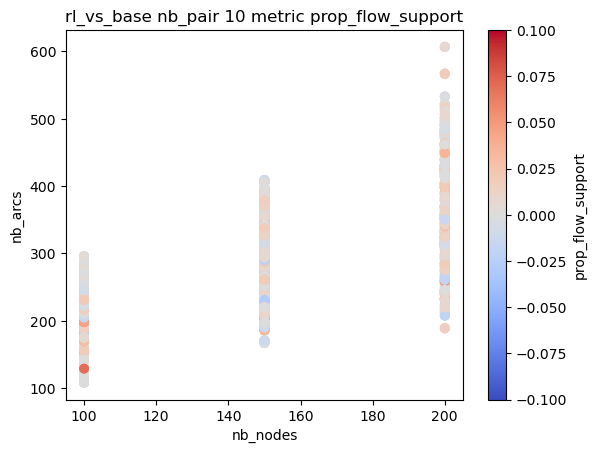

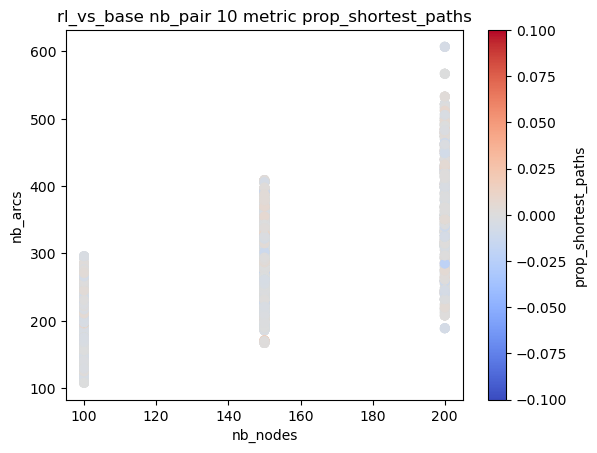

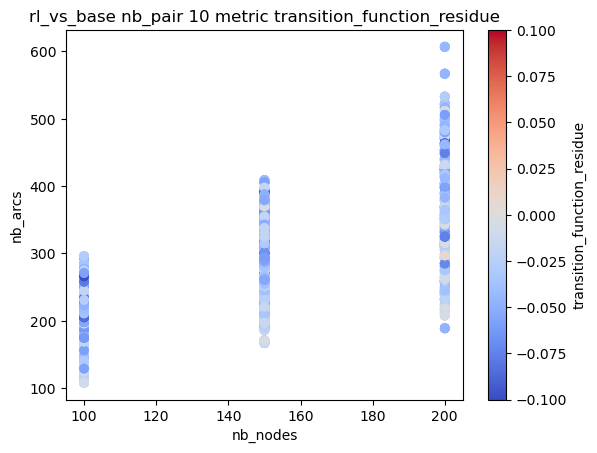

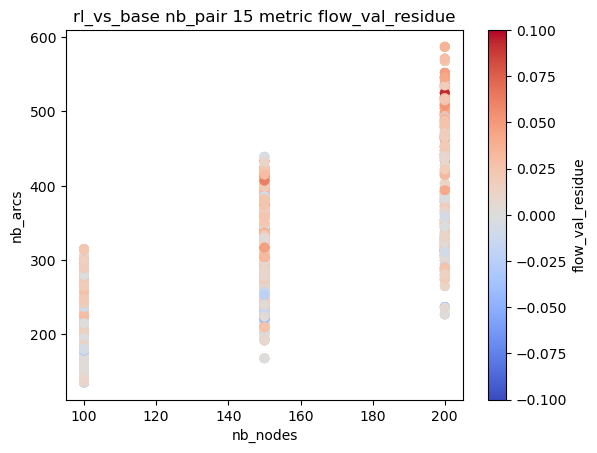

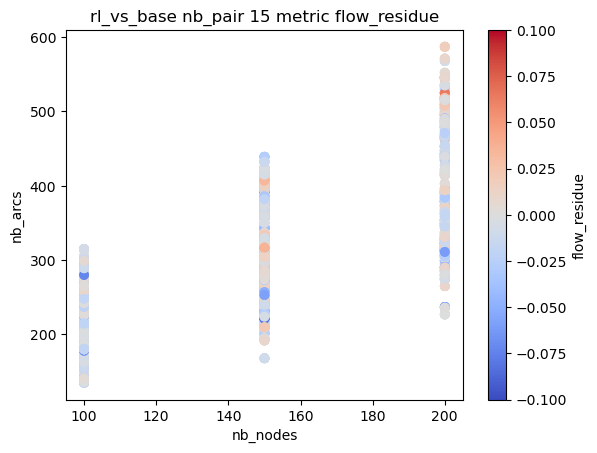

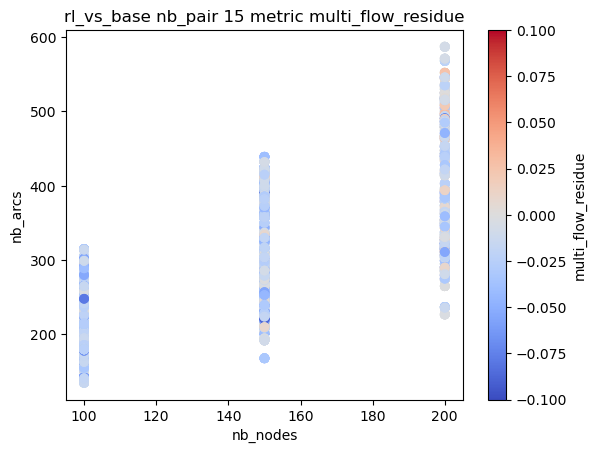

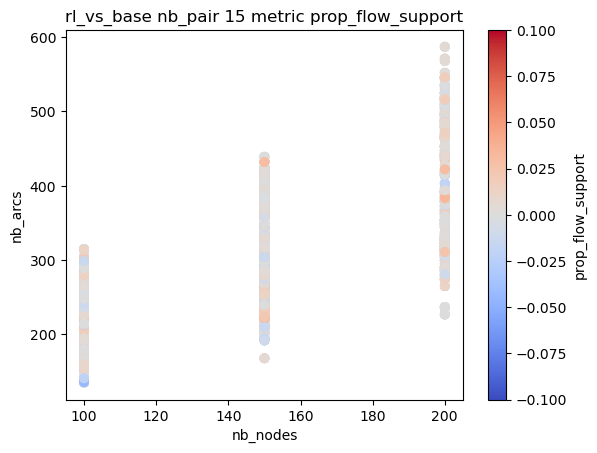

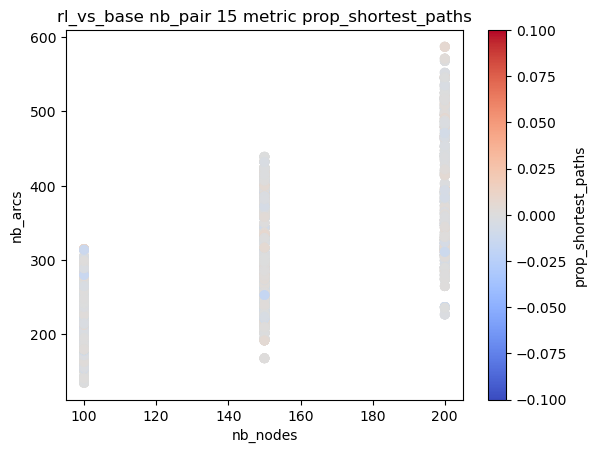

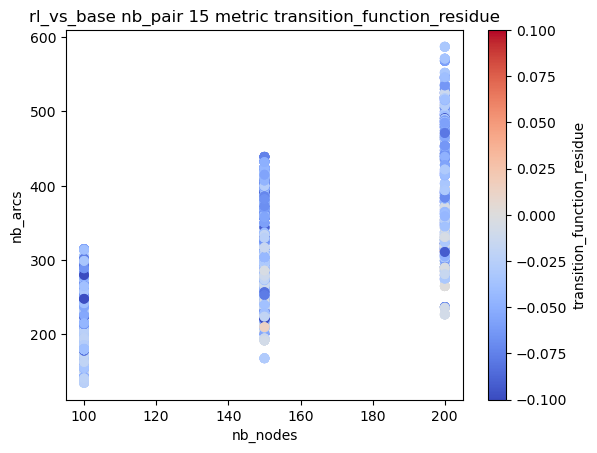

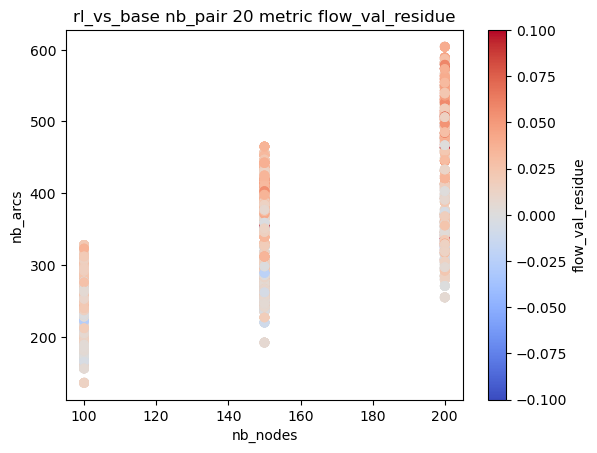

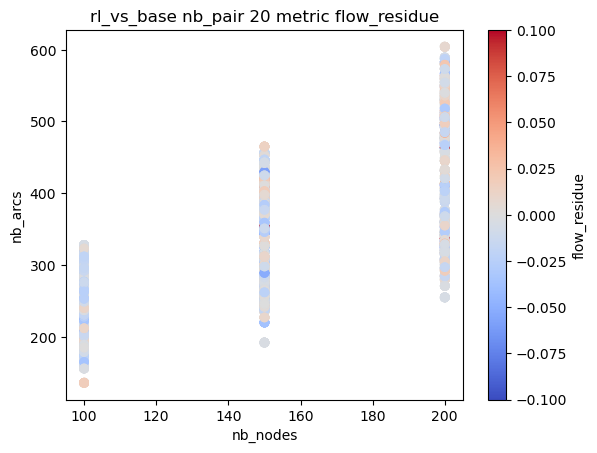

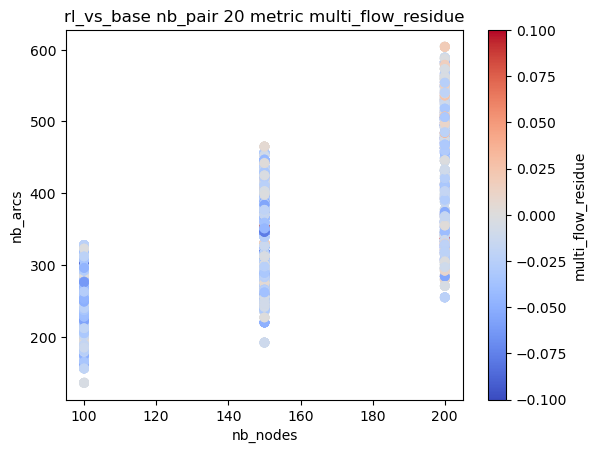

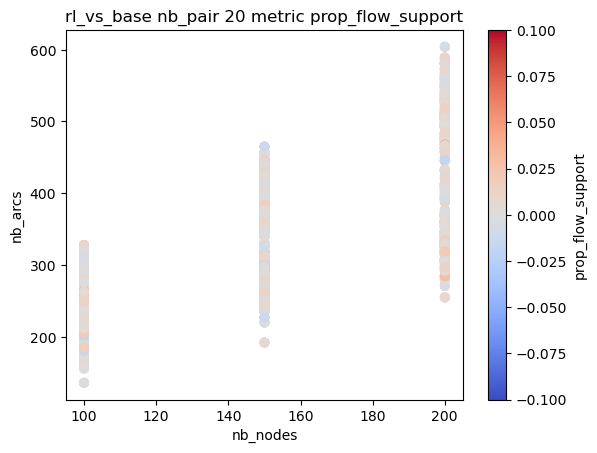

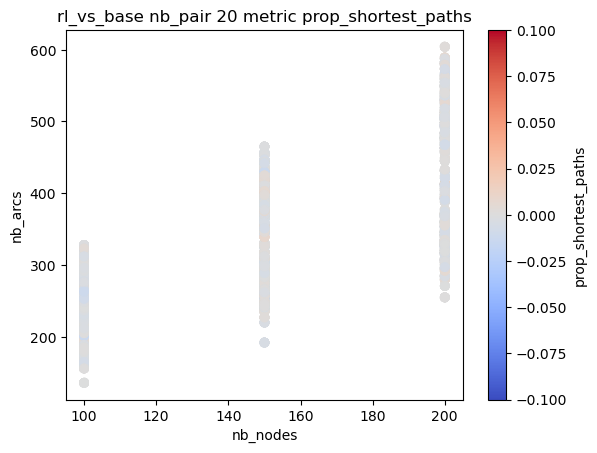

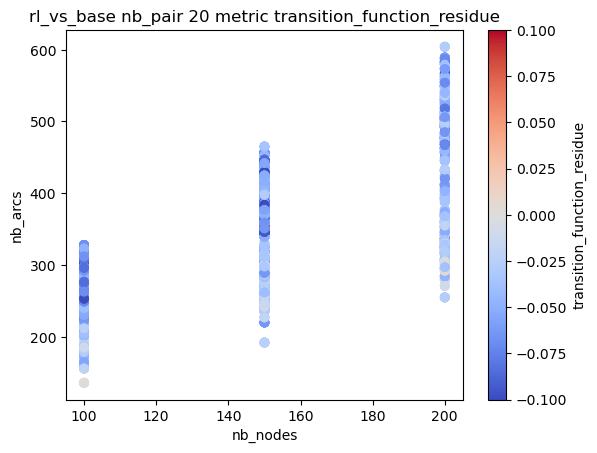

In [ ]:
"""
Comparison of baseline heuristics methods
"""

# Import pickle
import pickle

import numpy as np

import matplotlib.pyplot as plt

import statsmodels.api as sm

import seaborn as sns

import pylab as py

import scipy.stats as stats

from itertools import product

from IPython.display import clear_output

import os

os.chdir('C:\\Users\\HADDAM\\Documents\\Python Scripts\\multi_flow_decomp\\')

from utils.utils_stats import mean_confidence_interval, test_twoind_sample

from utils.graph_utils import get_nb_nodes, get_arcs



##########################  Baseline heuristics handling  ########################## 
"""
{"res_key_metadata":res_key_metadata,
"res_value_metadata":res_value_metadata, 
"data":deepcopy(dict(dict_results))}
"""
"""
    dict_results[(ind_instance, test)] = (flow_val_res, flow_res, m_flow_res, 
                                            prop_fsupp, prop_sp, trans_func_res)
    test   -->    ["min_time", 
                "max_capacity", 
                "trans_func", 
                "random"]
"""



"""
    {"res_key_metadata":res_key_metadata,
    "res_value_metadata":res_value_metadata, 
    "data":deepcopy(dict(dict_results))}
"""
"""
dict_results[(ind_instance, test_infos)] = (flow_val_res, flow_res, 
                                            m_flow_res, prop_fsupp, 
                                            prop_sp, trans_func_res,
                                            reward)
test_infos = (path_type_selector, path_card_criteria, lr_rate, (coeff1, coeff2, coeff3))
"""


heurs_algo_type = "min_time"

path_selection_type = "rl_arc_based"

path_card_criteria = "one_only"

show_arc_based = True

show_node_based = False


ls_vals_nb_nodes = [100, 150, 200]

ls_vals_nb_pairs = [10, 15, 20]

ls_vals_degrees = [3, 4]

ls_param_vals = list(product(ls_vals_nb_nodes, ls_vals_nb_pairs, ls_vals_degrees))


dict_inst_to_cards = {}
dir_path_instances = "data/simulated_data/complete_instances/node_pairs/small_world_like/capacity_factor=14/"
for a, b, c in ls_param_vals:
    file_path = dir_path_instances+"nb_nodes="+str(a)+"_nb_pairs="+str(b)+"_nb_neighbours="+str(c)+".npy"
    dict_data = np.load(file_path, allow_pickle=True).flatten()[0]
    for key in dict_data:
        ind_instance = key[0]
        graph = dict_data[key][0].adj_mat
        nb_nodes = get_nb_nodes(graph)
        nb_arcs = len(get_arcs(graph))
        dict_inst_to_cards[(a, b, c, ind_instance)] = (nb_nodes, nb_arcs)


dict_results_instances = {}
for a, b, c in ls_param_vals:
    fl_name = "baseline_heuristics_nb_nodes="+str(a)+"_nb_pairs="+str(b)+"_nb_neighbours="+str(c)+".gpickle"
    
    path_baseline_heuristics = "results/simulated/MFDS_vs_RL/stored_results_executions/small_worldlike_adajcency_list_instances/capacity_factor=14/baseline_heuristics/"+fl_name
    with open(path_baseline_heuristics, 
            'rb') as handle:
        file = pickle.load(handle)
        test_names = file["res_key_metadata"]
        metric_names = file["res_value_metadata"]
        data_res_heur = file["data"]
    

    nb_instances = len({id_inst for id_inst, _ in data_res_heur.keys()})

In [6]:
"""
Comp baseline heuristics
"""

# Import pickle
import pickle

import numpy as np

import matplotlib.pyplot as plt

import statsmodels.api as sm

import seaborn as sns

import pylab as py

import scipy.stats as stats

from itertools import product

from IPython.display import clear_output

import os

import sys

import pprint

os.chdir('C:\\Users\\HADDAM\\Documents\\Python Scripts\\multi_flow_decomp\\')

from utils.graph_utils import get_nb_nodes, get_arcs



##########################  Baseline heuristics handling  ########################## 
"""
{"res_key_metadata":res_key_metadata,
"res_value_metadata":res_value_metadata, 
"data":deepcopy(dict(dict_results))}
"""
"""
    dict_results[(ind_instance, test)] = (flow_val_res, flow_res, m_flow_res, 
                                            prop_fsupp, prop_sp, trans_func_res)
    test   -->    ["min_time", 
                "max_capacity", 
                "trans_func", 
                "random"]
"""



"""
    {"res_key_metadata":res_key_metadata,
    "res_value_metadata":res_value_metadata, 
    "data":deepcopy(dict(dict_results))}
"""
"""
dict_results[(ind_instance, test_infos)] = (flow_val_res, flow_res, 
                                            m_flow_res, prop_fsupp, 
                                            prop_sp, trans_func_res,
                                            reward)
test_infos = (path_type_selector, path_card_criteria, lr_rate, (coeff1, coeff2, coeff3))
"""


ls_vals_nb_nodes = [100, 150, 200]

ls_vals_nb_pairs = [10, 15, 20]

ls_vals_degrees = [3, 4]

ls_param_vals = list(product(ls_vals_nb_nodes, ls_vals_nb_pairs, ls_vals_degrees))


dict_inst_to_cards = {}
dir_path_instances = "data/simulated_data/complete_instances/node_pairs/small_world_like/capacity_factor=14/"
for a, b, c in ls_param_vals:
    file_path = dir_path_instances+"nb_nodes="+str(a)+"_nb_pairs="+str(b)+"_nb_neighbours="+str(c)+".npy"
    dict_data = np.load(file_path, allow_pickle=True).flatten()[0]
    for key in dict_data:
        ind_instance = key[0]
        graph = dict_data[key][0].adj_mat
        nb_nodes = get_nb_nodes(graph)
        nb_arcs = len(get_arcs(graph))
        dict_inst_to_cards[(a, b, c, ind_instance)] = (nb_nodes, nb_arcs)



# Calculate the mean performances of the basic heuristcis
dict_results_instances = {}
perfs_dict_heurs = {}
for a, b, c in ls_param_vals:
    fl_name = "baseline_heuristics_nb_nodes="+str(a)+"_nb_pairs="+str(b)+"_nb_neighbours="+str(c)+".gpickle"
    
    path_baseline_heuristics = "results/simulated/MFDS_vs_RL/stored_results_executions/small_worldlike_adajcency_list_instances/capacity_factor=14/baseline_heuristics/"+fl_name
    with open(path_baseline_heuristics, 
            'rb') as handle:
        file = pickle.load(handle)
        test_names = file["res_key_metadata"]
        metric_names = file["res_value_metadata"]
        data_res_heur = file["data"]

    nb_instances = len({id_inst for id_inst, _ in data_res_heur.keys()})
    for heurs_algo_type in test_names:
        for j in range(len(metric_names)):
            perfs_ls = [data_res_heur[(ind_instance, (heurs_algo_type,))][j]
                            for ind_instance in range(nb_instances)]
            
            if (heurs_algo_type, j) not in perfs_dict_heurs:
                perfs_dict_heurs[(metric_names[j], heurs_algo_type)] = perfs_ls
            else:
                perfs_dict_heurs[(metric_names[j], heurs_algo_type)].extend(perfs_ls)


for key in perfs_dict_heurs:
    perfs_dict_heurs[key] = (float(round(np.mean(perfs_dict_heurs[key]), 3)), 
                       float(round(np.std(perfs_dict_heurs[key], ddof=1), 3)))



# Calculate the mean performances of the rl node based heuristics
dict_results_instances = {}
perfs_dict_rl_node = {}
for a, b, c in ls_param_vals:
    fl_name = "rl_heuristics_nb_nodes="+str(a)+"_nb_pairs="+str(b)+"_nb_neighbours="+str(c)+".gpickle"
    
    path_baseline_heuristics = "results/simulated/MFDS_vs_RL/stored_results_executions/small_worldlike_adajcency_list_instances/capacity_factor=14/rl_heuristics/node_based/"+fl_name
    with open(path_baseline_heuristics, 
            'rb') as handle:
        file = pickle.load(handle)
        res_key_metadata = file["res_key_metadata"]
        res_value_metadata = file["res_value_metadata"]
        data_res_rl_heur = file["data"]
    

    nb_instances = len({id_inst for id_inst, _ in data_res_rl_heur.keys()})
    for j in range(len(metric_names)):
        perfs_ls = [data_res_rl_heur[key][j] for key in data_res_rl_heur]
                
        if (heurs_algo_type, j) not in perfs_dict_rl_node:
            perfs_dict_rl_node[(metric_names[j], "rl_node_based")] = perfs_ls
        else:
            perfs_dict_rl_node[(metric_names[j], "rl_node_based")].extend(perfs_ls)

for key in perfs_dict_rl_node:
    perfs_dict_rl_node[key] = (float(round(np.mean(perfs_dict_rl_node[key]), 3)), 
                                float(round(np.std(perfs_dict_rl_node[key], ddof=1), 3)))



# Calculate the mean performances of the rl arc based heuristics
dict_results_instances = {}
perfs_dict_rl_arc = {}
for a, b, c in ls_param_vals:
    fl_name = "rl_heuristics_nb_nodes="+str(a)+"_nb_pairs="+str(b)+"_nb_neighbours="+str(c)+".gpickle"
    
    path_baseline_heuristics = "results/simulated/MFDS_vs_RL/stored_results_executions/small_worldlike_adajcency_list_instances/capacity_factor=14/rl_heuristics/arc_based/"+fl_name
    with open(path_baseline_heuristics, 
            'rb') as handle:
        file = pickle.load(handle)
        res_key_metadata = file["res_key_metadata"]
        res_value_metadata = file["res_value_metadata"]
        data_res_rl_heur = file["data"]
    

    nb_instances = len({id_inst for id_inst, _ in data_res_rl_heur.keys()})
    for j in range(len(metric_names)):
        perfs_ls = [data_res_rl_heur[key][j] for key in data_res_rl_heur]
                
        if (heurs_algo_type, j) not in perfs_dict_rl_arc:
            perfs_dict_rl_arc[(metric_names[j], "rl_arc_based")] = perfs_ls
        else:
            perfs_dict_rl_arc[(metric_names[j], "rl_arc_based")].extend(perfs_ls)

for key in perfs_dict_rl_arc:
    perfs_dict_rl_arc[key] = (float(round(np.mean(perfs_dict_rl_arc[key]), 3)), 
                                float(round(np.std(perfs_dict_rl_arc[key], ddof=1), 3)))



print("       "+" ".join(metric_names))
for t_name in test_names:
    str_ = ""
    for metric_name in metric_names:
        str_ += str(perfs_dict_heurs[(metric_name, t_name)][0])+"+/-"+str(perfs_dict_heurs[(metric_name, t_name)][1])+" "
    print(t_name+" "+str_)


str_ = ""
for metric_name in metric_names:
    str_ += str(perfs_dict_rl_node[(metric_name, "rl_node_based")][0])+"+/-"+str(perfs_dict_rl_node[(metric_name, "rl_node_based")][1])+" "
print("rl_node_based "+str_)


str_ = ""
for metric_name in metric_names:
    str_ += str(perfs_dict_rl_arc[(metric_name, "rl_arc_based")][0])+"+/-"+str(perfs_dict_rl_arc[(metric_name, "rl_arc_based")][1])+" "
print("rl_arc_based "+str_)




       flow_val_residue flow_residue multi_flow_residue prop_flow_support prop_shortest_paths transition_function_residue
min_time 0.025+/-0.013 0.056+/-0.022 0.111+/-0.026 0.989+/-0.008 0.603+/-0.048 0.105+/-0.026 
max_capacity 0.233+/-0.164 0.229+/-0.192 0.254+/-0.063 0.899+/-0.144 0.629+/-0.063 0.295+/-0.145 
trans_func 0.186+/-0.082 0.144+/-0.077 0.205+/-0.045 0.991+/-0.012 0.592+/-0.048 0.134+/-0.07 
random 0.461+/-0.275 0.409+/-0.284 0.37+/-0.087 0.952+/-0.112 0.514+/-0.113 0.466+/-0.222 
rl_node_based 0.062+/-0.027 0.061+/-0.03 0.098+/-0.026 0.991+/-0.006 0.604+/-0.047 0.059+/-0.027 
rl_arc_based 0.057+/-0.018 0.053+/-0.017 0.097+/-0.023 0.992+/-0.006 0.602+/-0.047 0.051+/-0.016 
